In [9]:
import pandas as pd 
import numpy as np 
import matplotlib as mlt 

# Importing file and scanning 

scouting_data = pd.read_csv("pffScoutingData.csv")
scouting_data.head(10)

scouting_data.info()

len(scouting_data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188254 entries, 0 to 188253
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   gameId                     188254 non-null  int64 
 1    "playId"                  188254 non-null  int64 
 2    "nflId"                   188254 non-null  int64 
 3    "pff_role"                188254 non-null  object
 4    "pff_positionLinedUp"     188254 non-null  object
 5    "pff_hit"                 188254 non-null  object
 6    "pff_hurry"               188254 non-null  object
 7    "pff_sack"                188254 non-null  object
 8    "pff_beatenByDefender"    188254 non-null  object
 9    "pff_hitAllowed"          188254 non-null  object
 10   "pff_hurryAllowed"        188254 non-null  object
 11   "pff_sackAllowed"         188254 non-null  object
 12   "pff_nflIdBlockedPlayer"  188254 non-null  object
 13   "pff_blockType"           188254 non-null  

188254

In [25]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

scouting_data.columns = (scouting_data.columns.str.strip().str.replace('""', ''))
scouting_data = scouting_data.replace("NA", np.nan)

for col in scouting_data.select_dtypes(include = 'object').columns: 
    scouting_data[col] = scouting_data[col].str.strip()
    
    
# Converting numeric columns 
numeric_cols_pff = ["pff_hit", "pff_hurry", "pff_sack", "pff_beatenByDefender", "pff_hitAllowed", "pff_hurryAllowed", "pff_sackAllowed", "pff_backFieldBlock"]

for col in numeric_cols_pff: 
    scouting_data[col] = pd.to_numeric(scouting_data[col], errors = "coerce")

/var/folders/nj/mb90f17s1_74dyzqrw43kxdh0000gn/T/ipykernel_31562/3278280297.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = role_counts_pff.index, y = role_counts_pff.values, palette = "viridis")


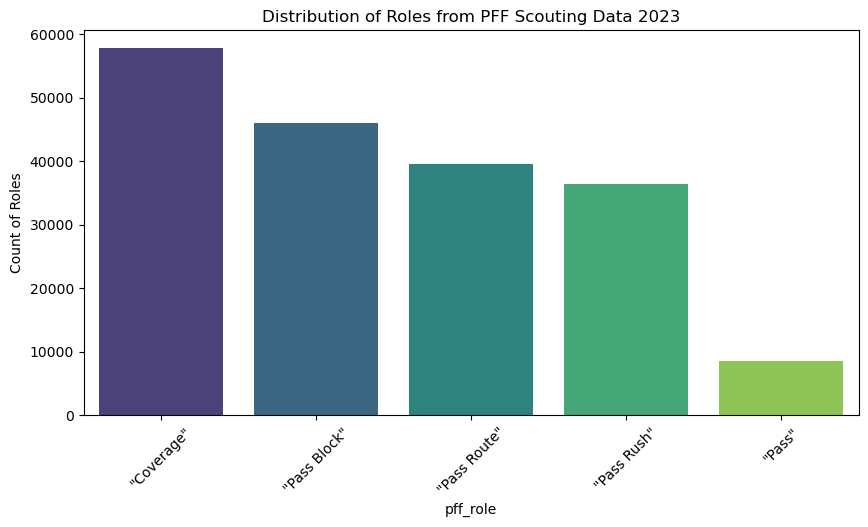

In [41]:
# Distribution of Roles 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

role_counts_pff = scouting_data["pff_role"].value_counts()

plt.figure(figsize = (10, 5))
sns.barplot(x = role_counts_pff.index, y = role_counts_pff.values, palette = "viridis")
plt.xticks(rotation = 45)
plt.title("Distribution of Roles from PFF Scouting Data 2023")
plt.ylabel("Count of Roles")
plt.show()

['"Pass"' '"Pass Route"' '"Pass Block"' '"Pass Rush"' '"Coverage"']


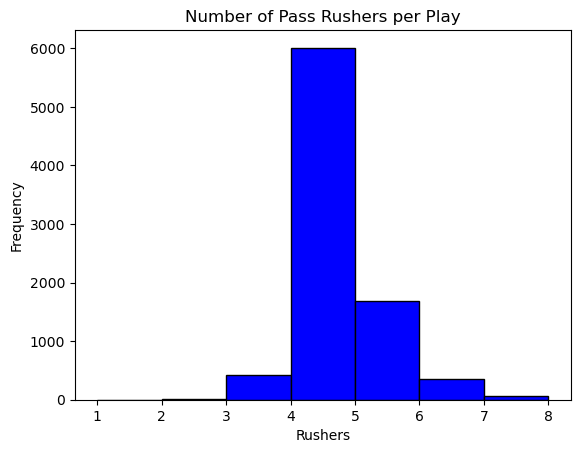

In [44]:
# Pass Rushers per Play

pass_rusher_values = scouting_data["pff_role"].unique()
print(pass_rusher_values)

rushers_pff = scouting_data[scouting_data["pff_role"] == '"Pass Rush"']

rushers_per_play = (
    rushers_pff
    .groupby(["gameId", "playId"])
    .size()
)

plt.hist(rushers_per_play, bins=range(1,9), edgecolor='black', color='blue')
plt.title("Number of Pass Rushers per Play")
plt.xlabel("Rushers")
plt.ylabel("Frequency")
plt.show()

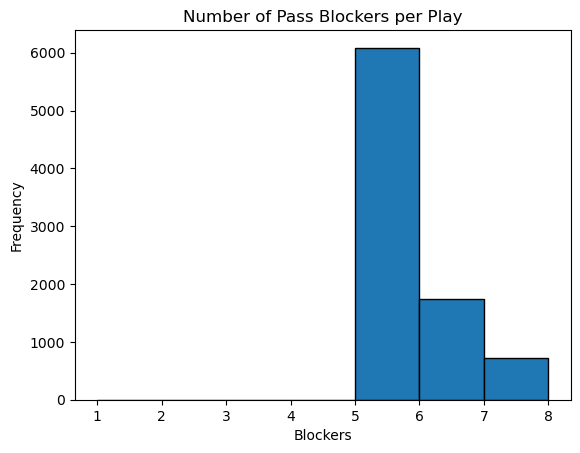

In [32]:
# Blockers Per Play

blockers_pff = scouting_data[scouting_data["pff_role"] == '"Pass Block"']

blockers_per_play = (
    blockers_pff
    .groupby(["gameId", "playId"])
    .size()
)

plt.hist(blockers_per_play, bins=range(1,9), edgecolor='black')
plt.title("Number of Pass Blockers per Play")
plt.xlabel("Blockers")
plt.ylabel("Frequency")
plt.show()

/var/folders/nj/mb90f17s1_74dyzqrw43kxdh0000gn/T/ipykernel_31562/3445866329.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=blockers_pff, x="pff_blockType", palette = "viridis")


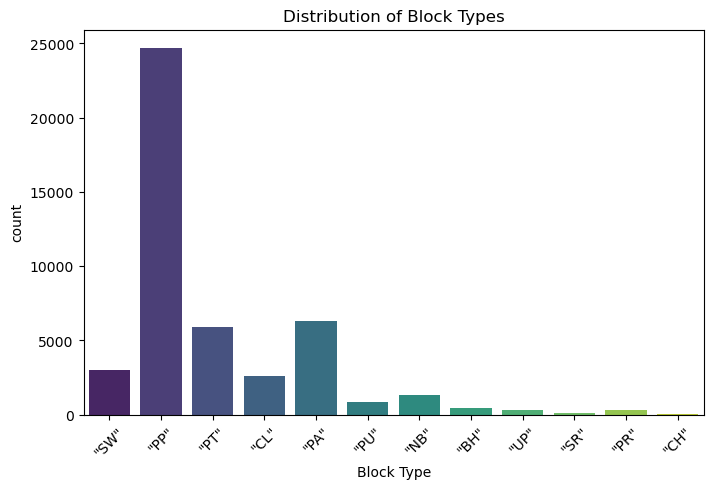

In [45]:
# Block Type Distribution 

plt.figure(figsize=(8,5))
sns.countplot(data=blockers_pff, x="pff_blockType", palette = "viridis")
plt.title("Distribution of Block Types")
plt.xticks(rotation=45)
plt.xlabel("Block Type")
plt.show()

/var/folders/nj/mb90f17s1_74dyzqrw43kxdh0000gn/T/ipykernel_31562/1448788307.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = rusher_alignments_pff.index, y = rusher_alignments_pff.values, palette = "plasma")


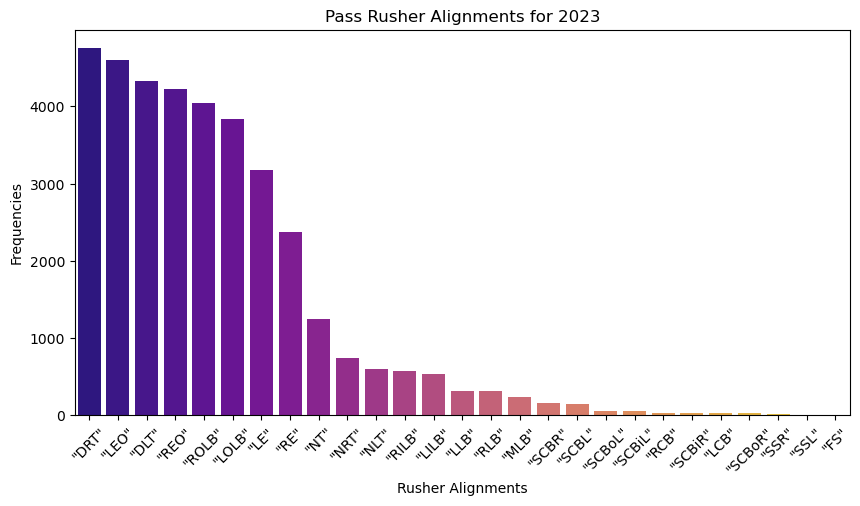

In [46]:
# Rusher Alignment Analysis 

rusher_alignments_pff = rushers_pff["pff_positionLinedUp"].value_counts()

plt.figure(figsize = (10, 5))
sns.barplot(x = rusher_alignments_pff.index, y = rusher_alignments_pff.values, palette = "plasma")
plt.title("Pass Rusher Alignments for 2023")
plt.xticks(rotation = 45)
plt.xlabel("Rusher Alignments")
plt.ylabel("Frequencies")
plt.show()